In [35]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [36]:
data_bookings = pd.read_csv('../data/hotel_bookings.csv')
print(data_bookings.head())

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

In [37]:
print(data_bookings.info())
print(data_bookings.describe())

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [38]:
print(data_bookings.columns)

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')


In [39]:
data_bookings.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [40]:
data_bookings['is_canceled'].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [41]:
cols_to_drop = [
    "reservation_status",
    "reservation_status_date",
    "agent",
    "company",
    "arrival_date_year",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "assigned_room_type",
    "country"  # optional
]

existing_cols = [col for col in cols_to_drop if col in data_bookings.columns]

data_bookings = data_bookings.drop(existing_cols, axis=1)

In [42]:
data_bookings.previous_bookings_not_canceled.mean()


np.float64(0.13709690928888515)

In [43]:
data_bookings.previous_cancellations.mean()

np.float64(0.08711784906608594)

In [44]:
data_bookings.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'booking_changes', 'deposit_type', 'days_in_waiting_list',
       'customer_type', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='str')

In [45]:
data_bookings.to_csv( '../data/cleaned_hotel_bookings.csv', index=False)

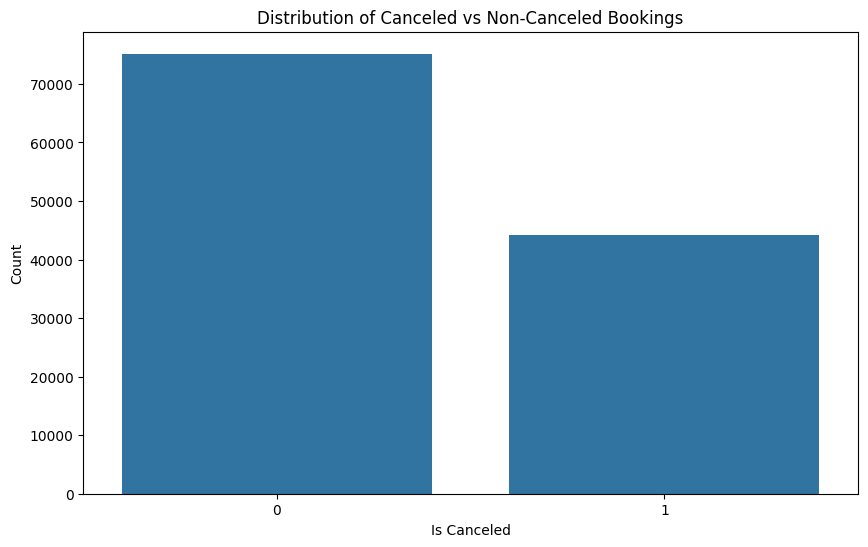

In [46]:
plt.figure(figsize=(10, 6))
sns.countplot(x='is_canceled', data=data_bookings)  
plt.title('Distribution of Canceled vs Non-Canceled Bookings')
plt.xlabel('Is Canceled')
plt.ylabel('Count')
plt.show()

In [48]:
data_bookings = pd.get_dummies(data_bookings, columns=['arrival_date_month'], drop_first=True)

KeyError: "None of [Index(['arrival_date_month'], dtype='str')] are in the [columns]"

In [50]:
import pandas as pd

# List of month dummy columns in calendar order
month_order = ['arrival_date_month_January', 'arrival_date_month_February', 'arrival_date_month_March',
               'arrival_date_month_April', 'arrival_date_month_May', 'arrival_date_month_June',
               'arrival_date_month_July', 'arrival_date_month_August', 'arrival_date_month_September',
               'arrival_date_month_October', 'arrival_date_month_November', 'arrival_date_month_December']

# Function to get month name from dummies
def get_month(row):
    for month_col in month_order:
        if row.get(month_col) == 1:
            return month_col.replace('arrival_date_month_', '')
    return 'Unknown'

# Create new column
data_bookings['arrival_date_month_combined'] = data_bookings.apply(get_month, axis=1)

# Make it categorical with calendar order
data_bookings['arrival_date_month_combined'] = pd.Categorical(
    data_bookings['arrival_date_month_combined'], 
    categories=['January','February','March','April','May','June','July','August',
                'September','October','November','December'], 
    ordered=True
)

# Quick check
data_bookings[['arrival_date_month_combined']].head()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16936\3409235652.py:20: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  data_bookings['arrival_date_month_combined'] = pd.Categorical(


,arrival_date_month_combined
0,July
1,July
2,July
3,July
4,July


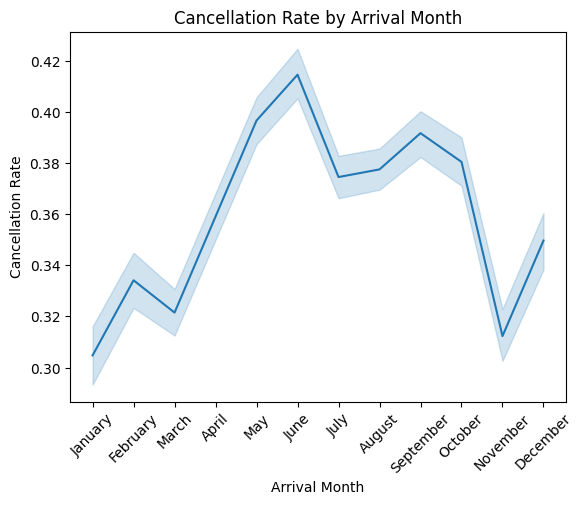

In [51]:
plt.Figure(figsize=(12, 6))
sns.lineplot(x='arrival_date_month_combined', y='is_canceled', data=data_bookings)
plt.title('Cancellation Rate by Arrival Month') 
plt.xlabel('Arrival Month')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=45)
plt.show()

In [64]:
data_bookings['total_guests'] = data_bookings['adults'] + data_bookings['children'] + data_bookings['babies']
data_bookings = data_bookings.drop(['adults', 'children', 'babies'], axis=1)

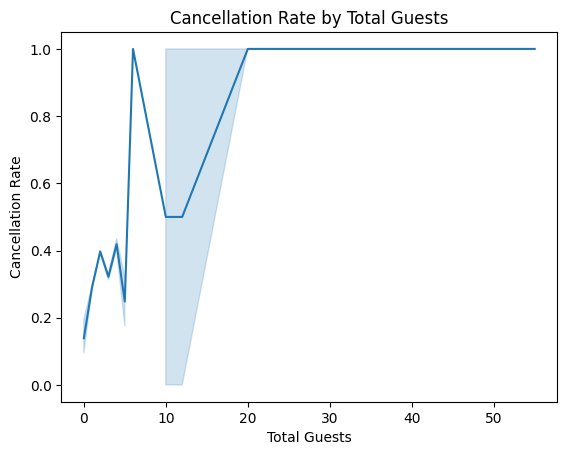

In [68]:
sns.lineplot(x='total_guests',y='is_canceled', data=data_bookings)
plt.title('Cancellation Rate by Total Guests')
plt.xlabel('Total Guests')
plt.ylabel('Cancellation Rate')
plt.show()

In [70]:
data_bookings.total_guests.mean()

np.float64(1.9682291055902703)

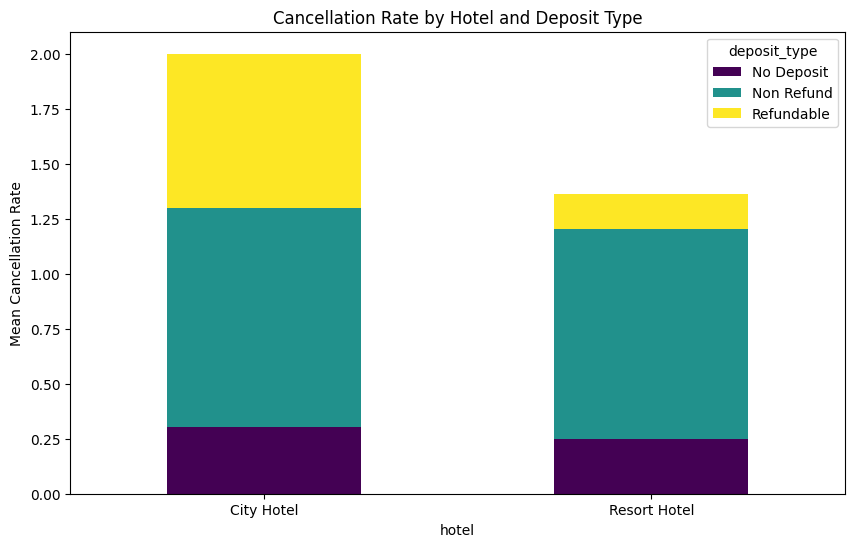

In [76]:
ct = pd.crosstab(
    data_bookings['hotel'], 
    data_bookings['deposit_type'], 
    values=data_bookings['is_canceled'], 
    aggfunc='mean'
)

# Plot
ct.plot(kind='bar', stacked=True, figsize=(10,6), colormap='viridis')
plt.ylabel('Mean Cancellation Rate')
plt.title('Cancellation Rate by Hotel and Deposit Type')
plt.xticks(rotation=0)
plt.show()

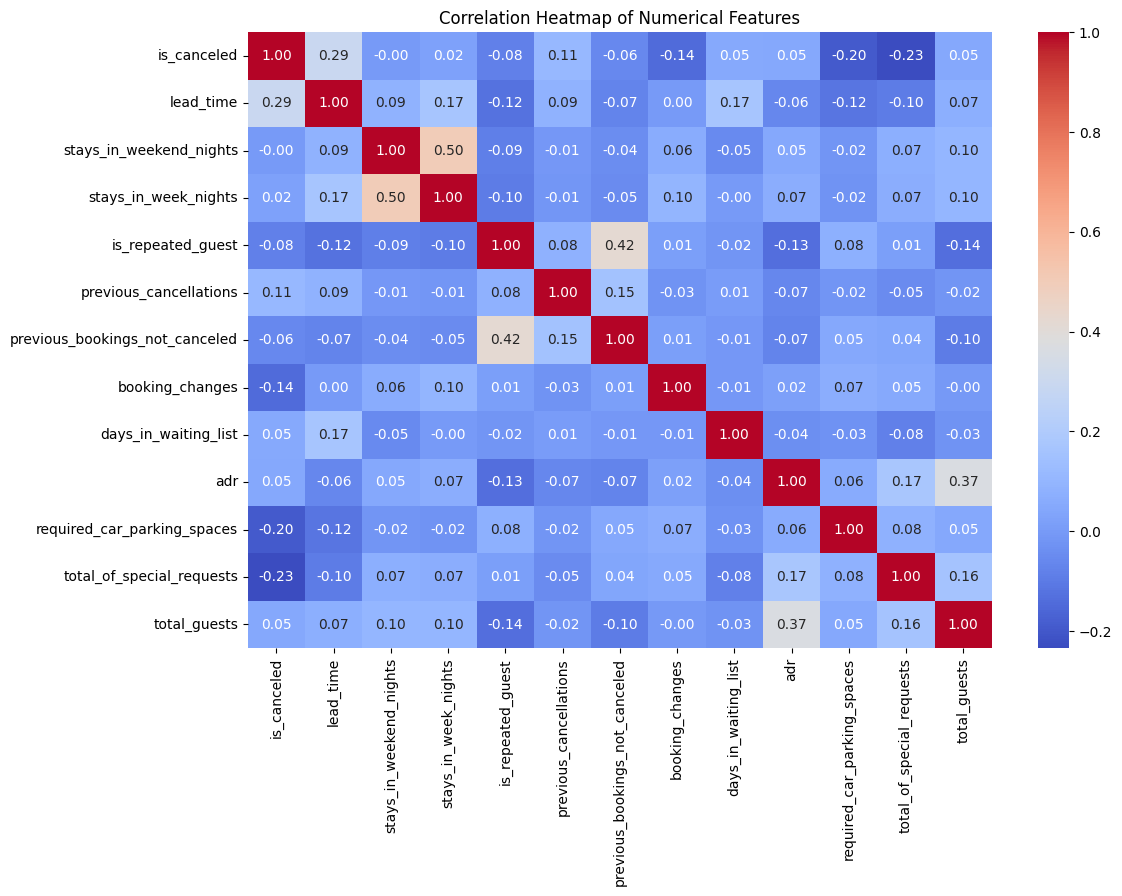

In [79]:
numeric_cols = data_bookings.select_dtypes(include='number').columns
data_corr = data_bookings[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(data_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()
